# DeepWalk neuronal — GCN enrichi (features structurelles)
Feature matrix riche (5 features) + GCN 3 couches + loss skip-gram

---

## 1 — Construction de la feature matrix enrichie

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_undirected
from torch_cluster import random_walk
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cpu


In [4]:
# ── Chargement & encodage ─────────────────────────────────────────────────────
DATA_PATH = 'graphe_complet_groupe.csv'
df = pd.read_csv(DATA_PATH)
df_agg = df.groupby(['user_id', 'original_author'], as_index=False)['nb_retweeted'].sum()

le = LabelEncoder()
all_ids = pd.concat([df_agg['user_id'], df_agg['original_author']]).unique()
le.fit(all_ids)
df_agg['src'] = le.transform(df_agg['user_id'])
df_agg['dst'] = le.transform(df_agg['original_author'])
N = len(le.classes_)
np.save('label_encoder_classes.npy', le.classes_)

print(f'Nœuds : {N:,}  |  Arcs : {len(df_agg):,}')

Nœuds : 83,291  |  Arcs : 112,858


In [5]:
# ── Construction du graphe NetworkX (non-orienté, pondéré) ────────────────────
print('Construction du graphe NetworkX...')
G_nx = nx.Graph()
G_nx.add_nodes_from(range(N))
G_nx.add_weighted_edges_from(
    zip(df_agg['src'], df_agg['dst'], df_agg['nb_retweeted'])
)
print(f'Graphe : {G_nx.number_of_nodes():,} nœuds, {G_nx.number_of_edges():,} arcs')

Construction du graphe NetworkX...
Graphe : 83,291 nœuds, 112,632 arcs


In [6]:
# ── Calcul des features structurelles ────────────────────────────────────────
# Toutes vectorisées ou via dict NetworkX pour éviter les boucles Python
print('Calcul des features structurelles (2-4 min)...')

nodes = list(range(N))

# 1. Degré (nombre de voisins)
degree_dict = dict(G_nx.degree())
degree = np.array([degree_dict.get(i, 0) for i in nodes], dtype=float)

# 2. Force (somme des poids des arcs — nb_retweeted)
strength_dict = dict(G_nx.degree(weight='weight'))
strength = np.array([strength_dict.get(i, 0) for i in nodes], dtype=float)

# 3. Coefficient de clustering local
# Mesure si les voisins d'un nœud se connaissent entre eux → signature de communauté
print('  → clustering...')
clustering_dict = nx.clustering(G_nx)
clustering = np.array([clustering_dict.get(i, 0) for i in nodes], dtype=float)

# 4. Degré moyen des voisins (ego-network density)
# Un nœud dans une communauté dense a des voisins eux-mêmes bien connectés
print('  → average neighbor degree...')
avg_neighbor_deg_dict = nx.average_neighbor_degree(G_nx)
avg_neighbor_deg = np.array([avg_neighbor_deg_dict.get(i, 0) for i in nodes], dtype=float)

# 5. Log-force normalisée (capture les hubs sans les écraser)
log_strength = np.log1p(strength)

# 6. Ratio force/degré (poids moyen par arc — intensité de la relation)
ratio_strength_degree = np.where(degree > 0, strength / degree, 0)

print('Features calculées.')
features_raw = np.column_stack([
    degree,
    clustering,
    avg_neighbor_deg,
    log_strength,
    ratio_strength_degree
])
print(f'Shape features : {features_raw.shape}')  # (N, 5)

Calcul des features structurelles (2-4 min)...
  → clustering...
  → average neighbor degree...
Features calculées.
Shape features : (83291, 5)


In [7]:
# ── Normalisation StandardScaler ──────────────────────────────────────────────
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_raw)
x_rich = torch.tensor(features_scaled, dtype=torch.float)

print(f'Feature matrix : {x_rich.shape}')
print(pd.DataFrame(features_raw, columns=[
    'degree','clustering','avg_neighbor_deg','log_strength','ratio_str_deg'
]).describe().round(3))

Feature matrix : torch.Size([83291, 5])
          degree  clustering  avg_neighbor_deg  log_strength  ratio_str_deg
count  83291.000   83291.000         83291.000     83291.000      83291.000
mean       2.705       0.022          1686.912         1.499          2.619
std       48.859       0.124          2629.928         0.655          1.721
min        1.000       0.000             1.000         1.099          2.000
25%        1.000       0.000            11.000         1.099          2.000
50%        1.000       0.000           308.000         1.099          2.000
75%        2.000       0.000          2462.083         1.609          3.000
max     9892.000       1.000          9892.000        10.529        134.000


In [8]:
# ── edge_index PyG (non-orienté) ─────────────────────────────────────────────
edge_index_dir = torch.tensor(
    np.stack([df_agg['src'].values, df_agg['dst'].values]), dtype=torch.long
)
edge_index = to_undirected(edge_index_dir, num_nodes=N)
print(f'edge_index : {edge_index.shape}')

edge_index : torch.Size([2, 225264])


## 2 — Architecture GCN enrichie

In [9]:
class GCNEmbedder(nn.Module):
    """
    GCN 3 couches avec BatchNorm et skip connections.
    Les skip connections permettent au gradient de circuler
    même si une couche n'apporte pas d'information utile.
    Sortie : embeddings normalisés L2 (N × out_dim)
    """
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim,      hidden_dim)
        self.conv2 = GCNConv(hidden_dim,  hidden_dim)
        self.conv3 = GCNConv(hidden_dim,  out_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        # Projection pour la skip connection (in_dim → hidden_dim)
        self.skip  = nn.Linear(in_dim, hidden_dim, bias=False)

    def forward(self, x, edge_index):
        # Couche 1
        h1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        h1 = h1 + self.skip(x)          # skip connection
        h1 = F.dropout(h1, p=0.2, training=self.training)
        # Couche 2
        h2 = F.relu(self.bn2(self.conv2(h1, edge_index)))
        h2 = h2 + h1                     # skip connection
        h2 = F.dropout(h2, p=0.2, training=self.training)
        # Couche 3 — projection finale
        out = self.conv3(h2, edge_index)
        return F.normalize(out, p=2, dim=1)  # L2 norm


# Hyperparamètres
IN_DIM          = x_rich.shape[1]   # 5
HIDDEN_DIM      = 128
EMBED_DIM       = 32
WALK_LENGTH     = 20
CONTEXT_SIZE    = 5
WALKS_PER_NODE  = 5
NEG_SAMPLES     = 10
EPOCHS          = 200
LR              = 0.01
NODES_PER_BATCH = 500
MAX_PAIRS       = 4096

model     = GCNEmbedder(IN_DIM, HIDDEN_DIM, EMBED_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=1, epochs=EPOCHS,
    pct_start=0.1
)

x_dev  = x_rich.to(device)
ei_dev = edge_index.to(device)
row    = ei_dev[0]
col    = ei_dev[1]

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres : {total_params:,}')
print(model)

Paramètres : 22,560
GCNEmbedder(
  (conv1): GCNConv(5, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 32)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (skip): Linear(in_features=5, out_features=128, bias=False)
)


## 3 — Loss skip-gram

In [10]:
def skipgram_loss(z, pos_pairs, neg_pairs):
    pos_score = (z[pos_pairs[:, 0]] * z[pos_pairs[:, 1]]).sum(dim=1)
    neg_score = (z[neg_pairs[:, 0]] * z[neg_pairs[:, 1]]).sum(dim=1)
    loss_pos  = F.binary_cross_entropy_with_logits(pos_score, torch.ones_like(pos_score))
    loss_neg  = F.binary_cross_entropy_with_logits(neg_score, torch.zeros_like(neg_score))
    return loss_pos + loss_neg


def generate_pairs(walk_tensor, context_size, neg_samples, n_nodes):
    pos_pairs = []
    num_walks, wlen = walk_tensor.shape
    for i in range(wlen):
        center = walk_tensor[:, i]
        for j in range(max(0, i - context_size), min(wlen, i + context_size + 1)):
            if j == i:
                continue
            pos_pairs.append(torch.stack([center, walk_tensor[:, j]], dim=1))
    pos_pairs = torch.cat(pos_pairs, dim=0)
    n = pos_pairs.shape[0]
    neg_ctx   = torch.randint(0, n_nodes, (n * neg_samples,), device=pos_pairs.device)
    neg_src   = pos_pairs[:, 0].repeat_interleave(neg_samples)
    neg_pairs = torch.stack([neg_src, neg_ctx], dim=1)
    return pos_pairs, neg_pairs

print('Fonctions définies.')

Fonctions définies.


## 4 — Entraînement

In [12]:
history = []
print(f"{'Epoch':>6}  {'Loss':>8}")
print('-' * 18)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    n_batches  = 0
    node_perm  = torch.randperm(N, device=device)

    # ── z détaché : utilisé pour calculer les scores des paires ─────────────
    # Le gradient NE passe PAS par z à chaque batch intermédiaire
    # → pas de conflit avec optimizer.step()
    with torch.no_grad():
        z_detached = model(x_dev, ei_dev)  # (N, 32) — pas de graphe de calcul

    accum_loss = torch.tensor(0.0, device=device, requires_grad=False)

    for batch_start in range(0, N, NODES_PER_BATCH):
        batch_nodes = node_perm[batch_start: batch_start + NODES_PER_BATCH]
        start = batch_nodes.repeat(WALKS_PER_NODE)
        walks = random_walk(row, col, start, walk_length=WALK_LENGTH)

        pos_pairs, neg_pairs = generate_pairs(walks, CONTEXT_SIZE, NEG_SAMPLES, N)

        if pos_pairs.shape[0] > MAX_PAIRS:
            idx       = torch.randperm(pos_pairs.shape[0], device=device)[:MAX_PAIRS]
            pos_pairs = pos_pairs[idx]
            neg_pairs = neg_pairs[idx.repeat_interleave(NEG_SAMPLES)[:MAX_PAIRS * NEG_SAMPLES]]

        # Score sur z détaché — pas de gradient ici
        loss_val = skipgram_loss(z_detached, pos_pairs, neg_pairs)
        accum_loss = accum_loss + loss_val.detach()
        n_batches += 1
        del walks, pos_pairs, neg_pairs

    # ── Un seul forward + backward propre à la fin de l'epoch ───────────────
    optimizer.zero_grad()
    z = model(x_dev, ei_dev)  # forward avec graphe de calcul

    # On ré-échantillonne un batch représentatif pour le backward
    sample_nodes = torch.randperm(N, device=device)[:NODES_PER_BATCH * 4]
    start_sample = sample_nodes.repeat(WALKS_PER_NODE)
    walks_sample = random_walk(row, col, start_sample, walk_length=WALK_LENGTH)
    pos_s, neg_s = generate_pairs(walks_sample, CONTEXT_SIZE, NEG_SAMPLES, N)

    if pos_s.shape[0] > MAX_PAIRS:
        idx   = torch.randperm(pos_s.shape[0], device=device)[:MAX_PAIRS]
        pos_s = pos_s[idx]
        neg_s = neg_s[idx.repeat_interleave(NEG_SAMPLES)[:MAX_PAIRS * NEG_SAMPLES]]

    loss_grad = skipgram_loss(z, pos_s, neg_s)
    loss_grad.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    epoch_loss = (accum_loss / n_batches).item()
    history.append(epoch_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {epoch_loss:>8.4f}')

print('\nEntraînement terminé.')

 Epoch      Loss
------------------
     1    1.3185
    10    1.1407
    20    1.1181
    30    1.1059
    40    1.0980
    50    1.0925
    60    1.0880
    70    1.0830
    80    1.0825
    90    1.0783
   100    1.0769
   110    1.0752
   120    1.0763
   130    1.0750


KeyboardInterrupt: 

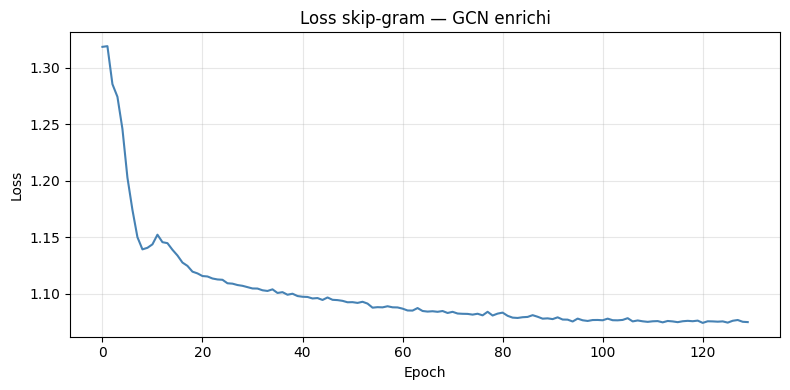

In [13]:
# ── Courbe de loss ────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history, color='steelblue')
plt.title('Loss skip-gram — GCN enrichi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5 — Embeddings, clustering & visualisation

In [14]:
model.eval()
with torch.no_grad():
    z_final = model(x_dev, ei_dev).cpu().numpy()  # (N, 32)

np.save('embeddings_gcn_rich_32d.npy', z_final)
print(f'Embeddings sauvegardés : {z_final.shape}')

Embeddings sauvegardés : (83291, 32)


In [15]:
# ── K-Means k=2 ───────────────────────────────────────────────────────────────
kmeans        = KMeans(n_clusters=2, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(z_final)

idx_sil = np.random.choice(N, size=min(10000, N), replace=False)
sil     = silhouette_score(z_final[idx_sil], cluster_labels[idx_sil])

print(f'Cluster 0 : {(cluster_labels==0).sum():,} nœuds')
print(f'Cluster 1 : {(cluster_labels==1).sum():,} nœuds')
print(f'Silhouette : {sil:.4f}')

Cluster 0 : 52,724 nœuds
Cluster 1 : 30,567 nœuds
Silhouette : 0.3824


In [16]:
# ── UMAP ──────────────────────────────────────────────────────────────────────
import umap

VIZ_SIZE = min(15000, N)
idx0 = np.where(cluster_labels == 0)[0]
idx1 = np.where(cluster_labels == 1)[0]
n0   = int(VIZ_SIZE * len(idx0) / N)
sample_idx = np.concatenate([
    np.random.choice(idx0, size=min(n0, len(idx0)), replace=False),
    np.random.choice(idx1, size=min(VIZ_SIZE - n0, len(idx1)), replace=False)
])

reducer = umap.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.05,
    metric='cosine', random_state=42
)
umap_2d       = reducer.fit_transform(z_final[sample_idx])
labels_sample = cluster_labels[sample_idx]

fig, ax = plt.subplots(figsize=(9, 7))
for cid, color, label in zip([0, 1], ['#2196F3', '#F44336'], ['Cluster 0', 'Cluster 1']):
    mask = labels_sample == cid
    ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1],
               c=color, s=4, alpha=0.5,
               label=f'{label} (n={mask.sum():,})')
ax.legend(markerscale=3, fontsize=11)
ax.set_title('GCN enrichi (5 features) + skip-gram — UMAP', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('gcn_rich_umap.png', dpi=150, bbox_inches='tight')
plt.show()


KeyboardInterrupt



In [17]:
# ── Export CSV ────────────────────────────────────────────────────────────────
df_emb = pd.DataFrame(z_final, columns=[f'emb_{i}' for i in range(EMBED_DIM)])
df_emb.insert(0, 'user_id', le.classes_)
df_emb['cluster'] = cluster_labels
df_emb.to_csv('embeddings_gcn_rich.csv', index=False)
print(f'Sauvegardé → embeddings_gcn_rich.csv  {df_emb.shape}')

Sauvegardé → embeddings_gcn_rich.csv  (83291, 34)
